In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
import os
from features_xtraction import features_extraction
from elbow_kmeans import elbow_kmeans
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sort_header import sort_header
from phase_probability import phase_probability

Preparing the data. 

In [2]:
# Making a dataframe. Here, every column represent a ECC in a timestep of the domain.
os.chdir('/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/Data/ECC')

path = r'/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/Data/ECC'

dataframe = pd.DataFrame()

#Going through every file in "dir".
for file in os.listdir(path):

    temp = pd.read_csv(file, header=None, sep=",")
    
    column_name = str(file).split(".")[0]
    
    dataframe[column_name] = temp
    
    #dataframe = dataframe.append(temp)

# Transposing the dataframe.
#dataframe = dataframe.T

# Adding a index row.
#dataframe.columns=range(0,864)

/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe[column_name] = temp
/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe[column_name] = temp
/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame

/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe[column_name] = temp
/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe[column_name] = temp
/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame

/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe[column_name] = temp
/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe[column_name] = temp
/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame

/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe[column_name] = temp
/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe[column_name] = temp
/tmp/ipykernel_2592/1989681073.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame

In [3]:
header = sort_header(list(dataframe))

In [4]:
dataframe = dataframe[header]

In [5]:
# Extrancting some statistical features from the dataframe
# This features are: *Mean *Variance *Autocorrelation
#                    *Nº of peaks with value grater than 2
#                    *Entropy
features_dataframe=features_extraction(dataframe)

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

...

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_index=True)
/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/features_xtraction.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  features_dataframe=features_dataframe.append({'Mean':mean, 'Variance':variance, 'Nº peaks':peaks, 'Entropy':entropy},ignore_i

Clusterization. 

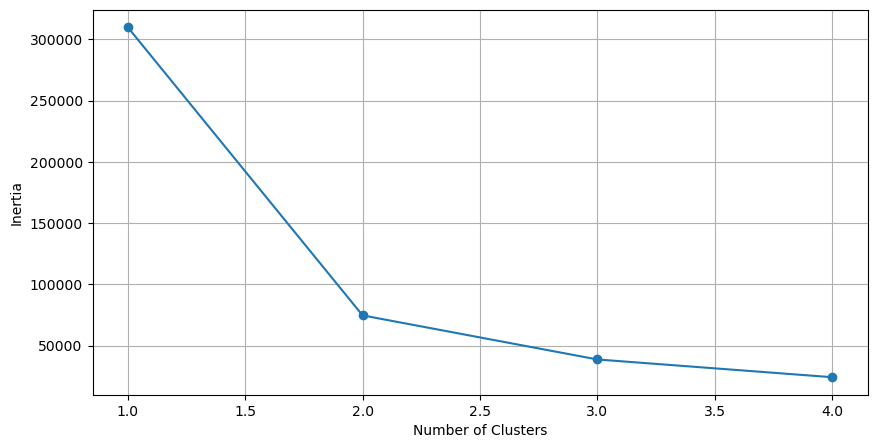

In [6]:
# Computing the optimum number of cluster and visualizing it.
elbow_kmeans(features_dataframe, 5)

In [7]:
# Going through the clusterization.
kmeans = KMeans(n_clusters=3)
kmeans.fit(features_dataframe)

KMeans(n_clusters=3)

In [8]:
# Adding a column to the feature dataframe related to the custerization labels.
features_dataframe['kmeans_3'] = kmeans.labels_

Getting the labels indexes. 

In [9]:
label_0 = [i for i, val in enumerate(features_dataframe['kmeans_3'] == 0) if val]

In [10]:
label_1 = [i for i, val in enumerate(features_dataframe['kmeans_3'] == 1) if val]

In [11]:
label_2 = [i for i, val in enumerate(features_dataframe['kmeans_3'] == 2) if val]

Ploting the clusters. 

Text(0, 0.5, 'EC')

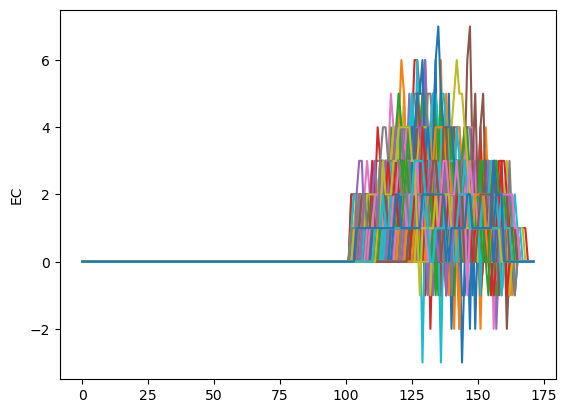

In [12]:
for i in label_0:
    index = list(dataframe)[i]
    plt.plot(range(0,172), dataframe[index])
plt.ylabel("EC")

Text(0, 0.5, 'EC')

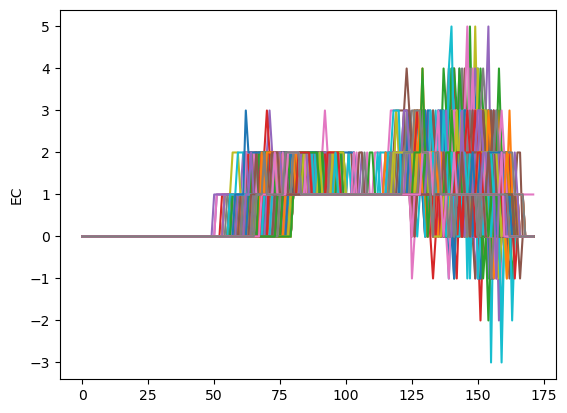

In [13]:
for i in label_1:
    index = list(dataframe)[i]
    plt.plot(range(0,172), dataframe[index])
plt.ylabel("EC")

Text(0, 0.5, 'EC')

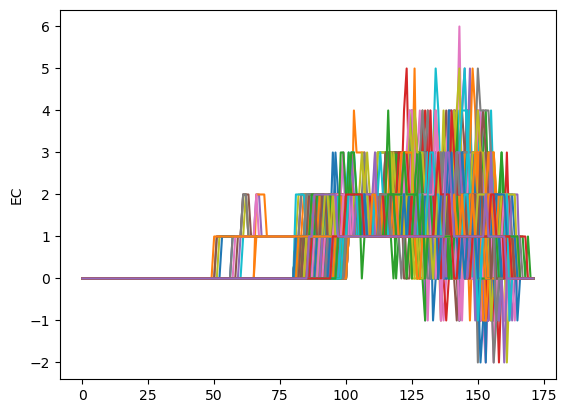

In [14]:
for i in label_2:
    index = list(dataframe)[i]
    plt.plot(range(0,172), dataframe[index])
plt.ylabel("EC")

Computing the matching of each cluester label with the ONI index.

In [15]:
#---------------------First, some paperwork.-------------------------------

In [16]:
cd ..

/home/oscar_amarilla/Nidtec/ML_TDA-ENSO/Data


In [17]:
ENSO_indexes = pd.read_csv('ENSO.csv', header=None, sep=",")[3]

In [18]:
#----------------------------------//--------------------------------------

In [19]:
phase_probability(ENSO_indexes[label_0].tolist())

Probability of neutral phase: 47 %
Probability of Ninha  phase: 20 %
Probability of Ninho phase: 33 %


[47, 20, 33]

In [20]:
phase_probability(ENSO_indexes[label_1].tolist())

Probability of neutral phase: 45 %
Probability of Ninha  phase: 39 %
Probability of Ninho phase: 16 %


[45, 39, 16]

In [21]:
phase_probability(ENSO_indexes[label_2].tolist())

Probability of neutral phase: 45 %
Probability of Ninha  phase: 24 %
Probability of Ninho phase: 32 %


[45, 24, 32]

Displaying a ONI index dataframe. 

In [22]:
aux = np.array(pd.DataFrame(ENSO_indexes).T)
oni=pd.DataFrame(aux[0][0:864].reshape(-1, 12)).T
oni.columns = range(1950,2022)
oni = oni.T
oni.columns=['DJF', 'JFM', 'FMA', 'MAM', 'AMJ', 'MJJ', 'JJA', 'JAS', 'ASO', 'SON', 'OND','NDJ']

In [23]:
oni

,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
1950,1,1,1,1,1,1,1,0,0,0,0,0
1951,0,0,0,0,0,2,2,2,2,2,2,2
1952,2,0,0,0,0,0,0,0,0,0,0,0
1953,0,2,2,2,2,2,2,2,2,2,2,2
1954,2,2,0,0,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2017,0,0,0,0,0,0,0,0,0,1,1,1
2018,1,1,1,1,0,0,0,0,2,2,2,2
2019,2,2,2,2,2,0,0,0,0,0,0,0
2020,0,0,0,0,0,0,0,1,1,1,1,1
